# Audio Captioning: Systematic Ablation Study

**Pipeline:** CLAP audio encoder (frozen) -> MLP projection -> Language Model  
**Dataset:** MusicCaps (~4,500 train / ~500 val / ~550 test)  
**Baseline:** 2-layer MLP, prefix_len=8, dropout=0.3, greedy decoding, LRs tuned per model (Optuna, 16 trials)  
**Noise floor:** 3 seeds per model (42, 43, 44) -- deltas below 1 std are not interpreted as effects

| Model | Type | Params | S1 Epochs | Batch |
|-------|------|--------|-----------|-------|
| GPT-2 | Decoder-only | 124M | 30 | 8 |
| T5-base | Encoder-decoder | 220M | 50 | 8 |
| Llama | Decoder-only | 1B | 40 | 4 |

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})

RESULTS_DIR = Path("../results")
MODELS = ["gpt2", "t5", "llama"]
METRICS = ["BLEU-1", "BLEU-4", "METEOR", "ROUGE-L", "CIDEr-D", "SPICE", "SPIDEr", "FENSE"]
PRIMARY = "FENSE"

In [3]:
def load_json(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


def collect_eval_results(ablation_type="arch"):
    rows = []
    for model in MODELS:
        ablation_dir = RESULTS_DIR / model / "ablations" / ablation_type
        if not ablation_dir.exists():
            continue
        for f in sorted(ablation_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            row = {"model": model, "tag": tag, **d["metrics"]}
            rows.append(row)
    return pd.DataFrame(rows)


def collect_training_results():
    rows = []
    for model in MODELS:
        training_dir = RESULTS_DIR / model / "training"
        if not training_dir.exists():
            continue
        for f in sorted(training_dir.glob(f"*_stage*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"_stage{d['stage']}", "")
            rows.append({
                "model": model, "tag": tag, "stage": d["stage"],
                "best_val_loss": d["best_val_loss"],
                "stopped_epoch": d["stopped_epoch"],
                "history": d["history"],
                "hyperparams": d["hyperparams"],
            })
    return rows


def load_noise_floors():
    floors = {}
    for model in MODELS:
        d = load_json(RESULTS_DIR / model / f"{model}_noise_floor.json")
        if d is None:
            continue
        floors[model] = {metric: d["noise_floor"][metric]["std"]
                         for metric in d["noise_floor"]}
    return floors


def style_ablation_table(df, model, floors, metrics):
    """Paper-style: bold best per column, baseline row shows +/- std."""
    floor = floors.get(model, {})
    baseline_tag = model

    # Build a string-typed DataFrame for display
    disp = pd.DataFrame(index=df.index, columns=metrics, dtype=str)
    for col in metrics:
        for idx in df.index:
            val = df.loc[idx, col]
            if idx == baseline_tag and col in floor:
                disp.loc[idx, col] = f"{val:.4f} ±{floor[col]:.4f}"
            else:
                disp.loc[idx, col] = f"{val:.4f}"

    # Bold best per column (compare on original numeric df)
    def bold_best(col):
        best = df[col.name].idxmax()
        return ["font-weight: bold" if idx == best else "" for idx in col.index]

    return disp.style.apply(bold_best, axis=0)


arch_df = collect_eval_results("arch")
decoding_df = collect_eval_results("decoding")
eval_df = pd.concat([arch_df, decoding_df], ignore_index=True) if len(decoding_df) > 0 else arch_df
training_results = collect_training_results()
noise_floors = load_noise_floors()

print(f"Loaded {len(arch_df)} arch + {len(decoding_df)} decoding eval results, "
      f"{len(training_results)} training results, {len(noise_floors)} noise floors")

Loaded 23 arch + 75 decoding eval results, 47 training results, 2 noise floors


## 1. Noise Floor (Run-to-Run Variance)

Measured via 3 training seeds (42, 43, 44) per model on identical test set.  
**Bold** = delta > 2 std (likely real). *Grey* = delta < 1 std (within noise).


  GPT2 -- Noise Floor (3 seeds)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
seed,,,,,,,,
42,0.309100,0.063100,0.126500,0.232900,0.110900,0.109100,0.110000,0.399800
43,0.312600,0.070200,0.133800,0.236100,0.125400,0.102700,0.114100,0.409500
44,0.309700,0.069200,0.133200,0.235600,0.122000,0.106400,0.114200,0.382400
std,0.001900,0.003900,0.004100,0.001700,0.007600,0.003200,0.002400,0.013700



  T5 -- Noise Floor (3 seeds)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
seed,,,,,,,,
42,0.300300,0.057400,0.116200,0.227500,0.084700,0.086600,0.085700,0.395400
43,0.316400,0.066300,0.123400,0.231400,0.096100,0.103200,0.099600,0.379000
44,0.292600,0.065100,0.120100,0.232800,0.120100,0.110800,0.115500,0.445200
std,0.012200,0.004800,0.003600,0.002700,0.018100,0.012400,0.014900,0.034500


LLAMA: noise floor not yet computed


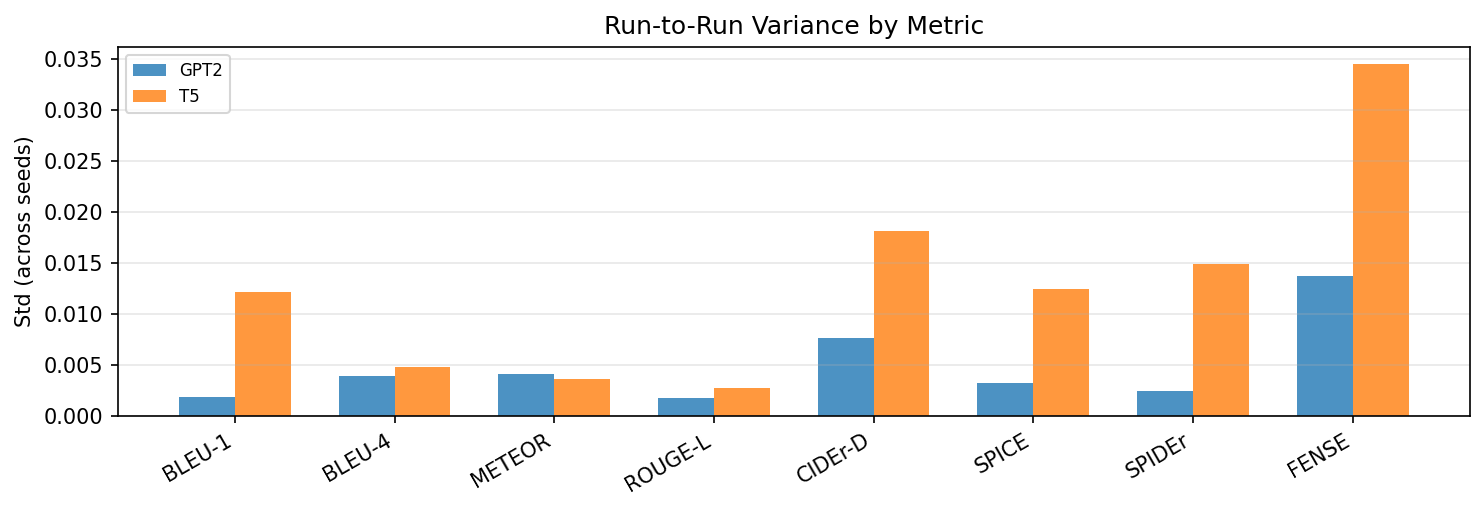

In [4]:
available = [m for m in METRICS if m in noise_floors.get(MODELS[0], {})]

for model in MODELS:
    nf_path = RESULTS_DIR / model / f"{model}_noise_floor.json"
    d = load_json(nf_path)
    if d is None:
        print(f"{model.upper()}: noise floor not yet computed")
        continue

    nf = d["noise_floor"]
    seeds = d["seeds"]
    rows = []
    for seed in seeds:
        row = {"seed": seed}
        for m in available:
            row[m] = nf[m]["values"][str(seed)]
        rows.append(row)
    row_stats = {"seed": "std"}
    for m in available:
        row_stats[m] = nf[m]["std"]
    rows.append(row_stats)

    nf_df = pd.DataFrame(rows).set_index("seed")
    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Noise Floor ({len(seeds)} seeds)")
    print(f"{'='*60}")
    styled = nf_df.round(4).style
    styled = styled.apply(lambda row: ["font-weight: bold" if row.name == "std" else ""
                                        for _ in row], axis=1)
    display(styled)

# Bar chart: noise floor std per metric, both models side by side
if noise_floors:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    x = np.arange(len(available))
    width = 0.35
    for i, model in enumerate(MODELS):
        if model not in noise_floors:
            continue
        stds = [noise_floors[model].get(m, 0) for m in available]
        ax.bar(x + i * width, stds, width, label=model.upper(), alpha=0.8)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(available, rotation=30, ha="right")
    ax.set_ylabel("Std (across seeds)")
    ax.set_title("Run-to-Run Variance by Metric")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

## 2. Baseline Comparison + S1/S2 Val Loss Spread

S1 trains only the projection; S2 fine-tunes the full LM.  
S2 collapses the S1 val loss spread -- final model quality should be judged by test-set captioning metrics, not val loss.

Baseline Test-Set Metrics


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
model,,,,,,,,
gpt2,0.309100,0.063100,0.126500,0.232900,0.110900,0.109100,0.110000,0.399800
t5,0.300300,0.057400,0.116200,0.227500,0.084700,0.086600,0.085700,0.395400
llama,0.310400,0.066900,0.131000,0.236500,0.117000,0.115600,0.116300,0.362600


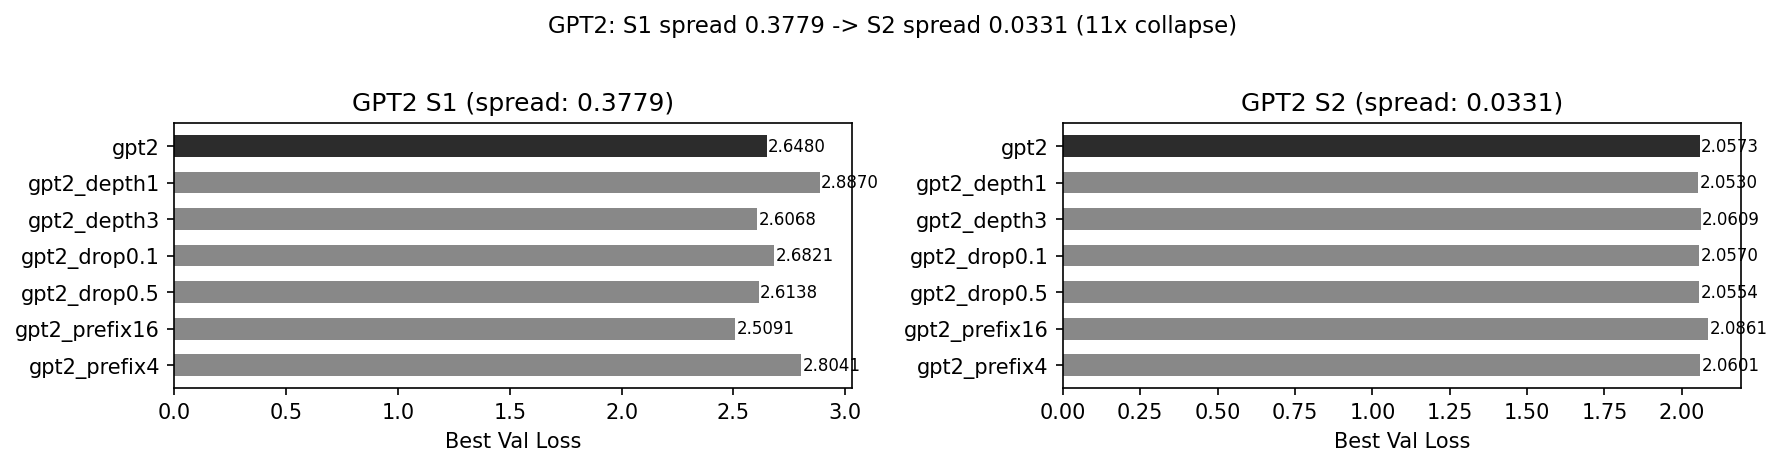

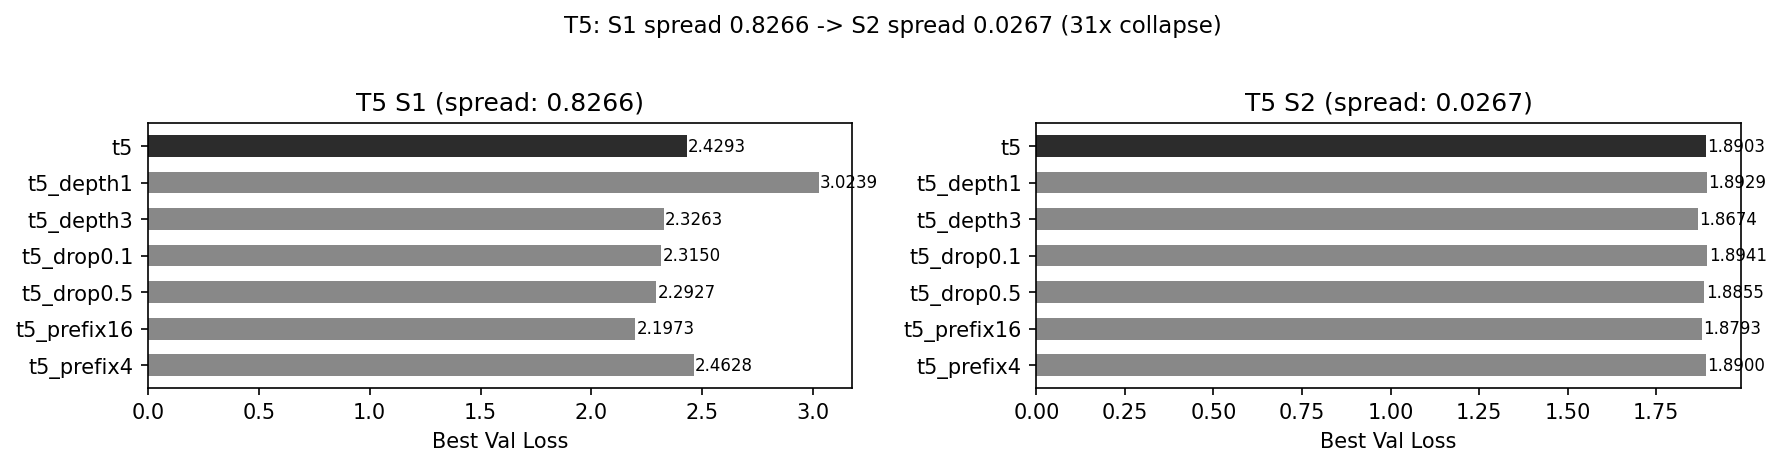

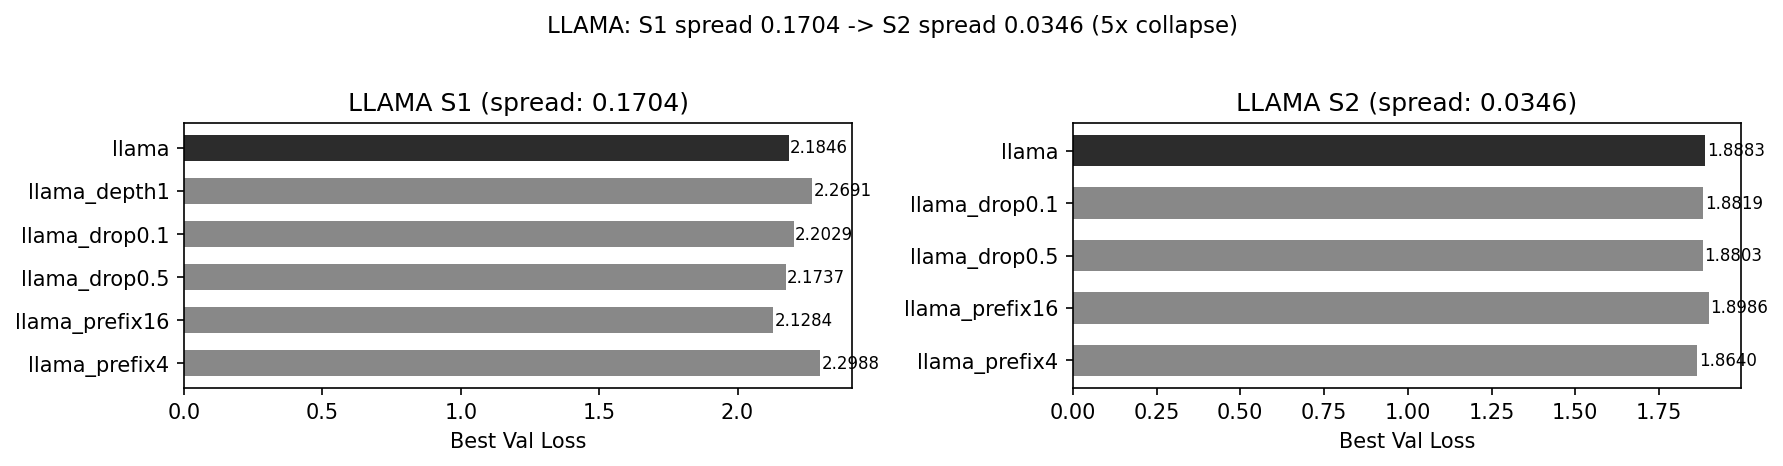

In [5]:
# --- Baseline metrics table ---
baselines = arch_df[arch_df["tag"] == arch_df["model"]].copy()
if len(baselines) > 0:
    avail = [m for m in METRICS if m in baselines.columns]
    bl = baselines.set_index("model")[avail].round(4)
    bl = bl.reindex([m for m in MODELS if m in bl.index])
    print("Baseline Test-Set Metrics")
    display(bl.style.background_gradient(cmap="Greys", vmin=-0.5, axis=None, subset=avail))

# --- S1 vs S2 val loss spread ---
for model in MODELS:
    model_training = [r for r in training_results if r["model"] == model]
    if not model_training:
        continue

    arch_tags = sorted(set(r["tag"] for r in model_training
                           if "seed" not in r["tag"] or r["tag"] == model))

    s1_rows, s2_rows = [], []
    for tag in arch_tags:
        for r in model_training:
            if r["tag"] != tag:
                continue
            row = {"config": tag, "best_val_loss": round(r["best_val_loss"], 4),
                   "stopped_epoch": r["stopped_epoch"]}
            if r["stage"] == 1:
                s1_rows.append(row)
            else:
                s2_rows.append(row)

    if not s1_rows or not s2_rows:
        continue

    s1_df = pd.DataFrame(s1_rows).set_index("config")
    s2_df = pd.DataFrame(s2_rows).set_index("config")
    s1_spread = s1_df["best_val_loss"].max() - s1_df["best_val_loss"].min()
    s2_spread = s2_df["best_val_loss"].max() - s2_df["best_val_loss"].min()

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
    for ax, (stage_df, label, spread) in zip(axes, [
        (s1_df, "S1", s1_spread), (s2_df, "S2", s2_spread)
    ]):
        vals = stage_df["best_val_loss"]
        colors = ["#2c2c2c" if t == model else "#888" for t in stage_df.index]
        ax.barh(stage_df.index, vals, color=colors, height=0.6)
        ax.set_xlabel("Best Val Loss")
        ax.set_title(f"{model.upper()} {label} (spread: {spread:.4f})")
        ax.invert_yaxis()
        for j, v in enumerate(vals):
            ax.text(v + 0.005, j, f"{v:.4f}", va="center", fontsize=8)
    plt.suptitle(f"{model.upper()}: S1 spread {s1_spread:.4f} -> S2 spread {s2_spread:.4f} "
                 f"({s1_spread / s2_spread:.0f}x collapse)", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 3. Architecture Ablations (Test-Set Metrics)

Baseline: depth=2, prefix_len=8, dropout=0.3, greedy decoding.  
Each variant changes one variable. Baseline row shows mean +/- std from seed replication. **Bold** = best per column.

In [6]:
for model in MODELS:
    model_df = arch_df[arch_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    model_df = model_df[~model_df["tag"].str.contains("seed")]
    avail = [m for m in METRICS if m in model_df.columns]
    table = model_df.set_index("tag")[avail].round(4)

    print(f"\n{model.upper()} -- Architecture Ablations")
    display(style_ablation_table(table, model, noise_floors, avail))


GPT2 -- Architecture Ablations


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
gpt2,0.3091 ±0.0019,0.0631 ±0.0039,0.1265 ±0.0041,0.2329 ±0.0017,0.1109 ±0.0076,0.1091 ±0.0032,0.1100 ±0.0024,0.3998 ±0.0137
gpt2_depth1,0.3103,0.0631,0.1288,0.2339,0.1078,0.1164,0.1121,0.3992
gpt2_depth3,0.2951,0.0600,0.1255,0.2201,0.0952,0.1000,0.0976,0.4002
gpt2_drop0.1,0.3106,0.0696,0.1337,0.2371,0.1268,0.1152,0.1210,0.4092
gpt2_drop0.5,0.3052,0.0653,0.1297,0.2317,0.1080,0.1050,0.1065,0.4316
gpt2_prefix16,0.3093,0.0698,0.1324,0.2345,0.1235,0.1118,0.1177,0.4199
gpt2_prefix4,0.3101,0.0638,0.1307,0.2327,0.1020,0.1004,0.1012,0.4221



T5 -- Architecture Ablations


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
t5,0.3003 ±0.0122,0.0574 ±0.0048,0.1162 ±0.0036,0.2275 ±0.0027,0.0847 ±0.0181,0.0866 ±0.0124,0.0857 ±0.0149,0.3954 ±0.0345
t5_depth1,0.2947,0.0546,0.1135,0.2267,0.0893,0.0953,0.0923,0.3755
t5_depth3,0.2400,0.0549,0.1044,0.2111,0.0968,0.0963,0.0965,0.4500
t5_drop0.1,0.2828,0.0570,0.1154,0.2291,0.1308,0.1044,0.1176,0.4389
t5_drop0.5,0.2877,0.0543,0.1143,0.2255,0.0971,0.0999,0.0985,0.3725
t5_prefix16,0.2508,0.0610,0.1095,0.2191,0.1263,0.1105,0.1184,0.4947
t5_prefix4,0.2683,0.0655,0.1157,0.2271,0.1240,0.1139,0.1190,0.4908



LLAMA -- Architecture Ablations


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
llama,0.3104,0.0669,0.1310,0.2365,0.1170,0.1156,0.1163,0.3626
llama_drop0.1,0.3046,0.0568,0.1282,0.2320,0.1019,0.1040,0.1030,0.4065
llama_drop0.5,0.2912,0.0602,0.1279,0.2227,0.1074,0.1166,0.1120,0.4060
llama_prefix16,0.2610,0.0517,0.1216,0.2105,0.0820,0.1138,0.0979,0.4045
llama_prefix4,0.2987,0.0688,0.1252,0.2286,0.1333,0.1159,0.1246,0.3838


## 4. Decoding Ablations (Test-Set Metrics)

Eval-only on baseline checkpoint -- no retraining. Top 15 configs per model by FENSE.  
Baseline row shows mean +/- std. **Bold** = best per column.


GPT2 -- Decoding Ablations (top 15 by FENSE)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
trim_ngram2,0.3171,0.0575,0.1210,0.2205,0.1092,0.1081,0.1087,0.5796
trim_rep1.2_ngram2_t0.3,0.2829,0.0454,0.1137,0.1970,0.1003,0.1062,0.1033,0.5775
trim_rep1.2_ngram3,0.2839,0.0407,0.1127,0.1944,0.0926,0.1045,0.0986,0.5766
trim_rep1.2_ngram2,0.2810,0.0409,0.1124,0.1931,0.0959,0.1042,0.1000,0.5766
trim_rep1.2,0.2834,0.0408,0.1124,0.1945,0.0924,0.1043,0.0983,0.5758
trim_rep1.3,0.2605,0.0374,0.1058,0.1843,0.0885,0.0990,0.0938,0.5723
trim_rep1.2_ngram2_t48,0.2011,0.0308,0.0938,0.1835,0.0692,0.1002,0.0847,0.5659
trim_incomplete,0.3091,0.0605,0.1202,0.2303,0.1106,0.1071,0.1088,0.5635
trim_rep1.8_ngram2_t0.3,0.2252,0.0348,0.0964,0.1708,0.0725,0.0940,0.0832,0.5589


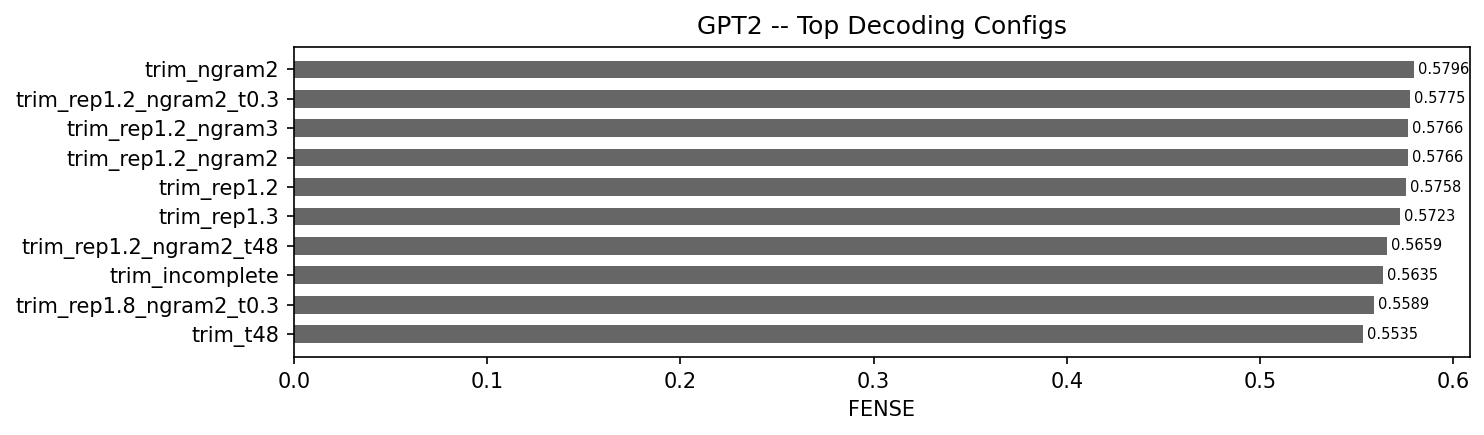


T5 -- Decoding Ablations (top 15 by FENSE)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
trim_rep1.2,0.3045,0.0498,0.1158,0.2203,0.0863,0.0921,0.0892,0.5762
trim_beam5_ngram2,0.1923,0.0428,0.0918,0.1967,0.0878,0.1013,0.0945,0.5649
trim_rep1.3,0.2934,0.0424,0.1124,0.2065,0.0779,0.0987,0.0883,0.5640
trim_rep1.2_beam5_ngram2,0.1956,0.0442,0.0941,0.1949,0.0985,0.1023,0.1004,0.5618
trim_rep1.2_ngram2,0.2527,0.0296,0.0982,0.1904,0.0662,0.1000,0.0831,0.5593
trim_rep1.2_ngram2_t0.3,0.2500,0.0331,0.0978,0.1897,0.0611,0.0973,0.0792,0.5591
trim_rep1.3_ngram2,0.2629,0.0331,0.1018,0.1926,0.0711,0.1019,0.0865,0.5570
trim_rep1.2_ngram3,0.2725,0.0371,0.1017,0.2063,0.0738,0.0903,0.0821,0.5546
trim_rep1.5,0.2579,0.0264,0.1010,0.1817,0.0653,0.0916,0.0785,0.5533


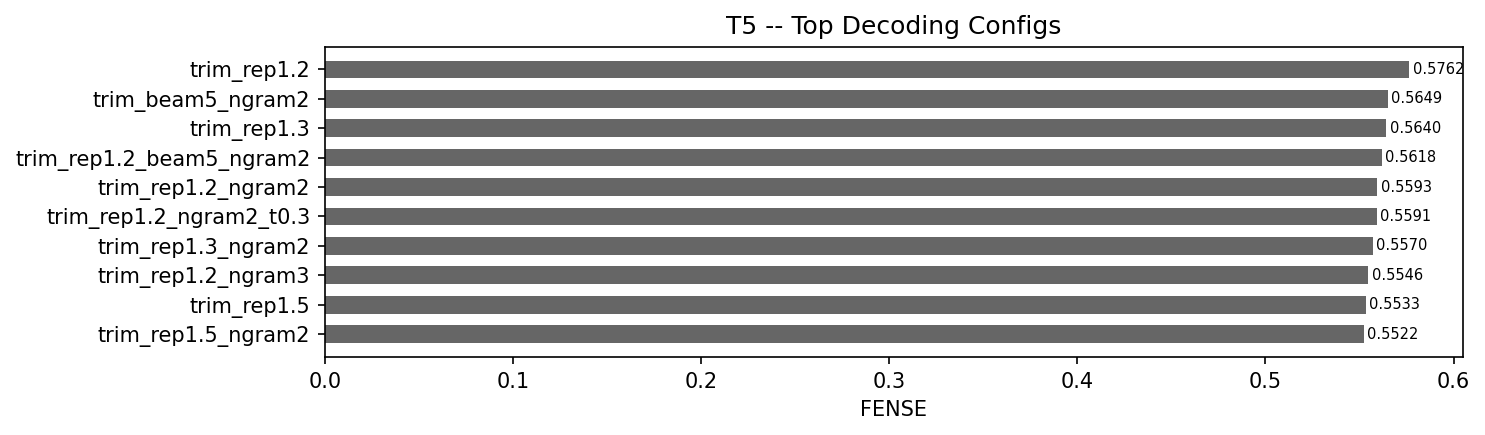

In [7]:
for model in MODELS:
    model_df = decoding_df[decoding_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    avail = [m for m in METRICS if m in model_df.columns]

    # Add baseline row for reference
    bl_row = arch_df[(arch_df["model"] == model) & (arch_df["tag"] == model)]
    if len(bl_row) > 0:
        bl_copy = bl_row.copy()
        bl_copy["tag"] = model
        model_df = pd.concat([bl_copy, model_df], ignore_index=True)

    table = model_df.set_index("tag")[avail].round(4)
    table = table.sort_values(PRIMARY, ascending=False).head(15)

    print(f"\n{model.upper()} -- Decoding Ablations (top 15 by {PRIMARY})")
    display(style_ablation_table(table, model, noise_floors, avail))

    # Bar chart: top configs by FENSE with noise floor lines
    top = table.head(10)
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["#2c2c2c" if t == model else "#666" for t in top.index]
    # Need numeric values for the bar chart
    top_numeric = decoding_df[decoding_df["model"] == model].copy()
    if len(bl_row) > 0:
        bl_c = bl_row.copy()
        bl_c["tag"] = model
        top_numeric = pd.concat([bl_c, top_numeric], ignore_index=True)
    top_numeric = top_numeric.set_index("tag")[avail].round(4)
    top_numeric = top_numeric.sort_values(PRIMARY, ascending=False).head(10)
    colors = ["#2c2c2c" if t == model else "#666" for t in top_numeric.index]

    ax.barh(top_numeric.index[::-1], top_numeric[PRIMARY][::-1], color=colors[::-1], height=0.6)
    if model in noise_floors and PRIMARY in noise_floors[model]:
        bl_val = top_numeric.loc[model, PRIMARY] if model in top_numeric.index else None
        if bl_val is not None:
            std = noise_floors[model][PRIMARY]
            ax.axvline(bl_val + std, color="red", linestyle="--", alpha=0.5, label=f"baseline + 1 std")
            ax.axvline(bl_val + 2 * std, color="red", linestyle=":", alpha=0.5, label=f"baseline + 2 std")
            ax.legend(fontsize=7)
    ax.set_xlabel(PRIMARY)
    ax.set_title(f"{model.upper()} -- Top Decoding Configs")
    for j, (idx, v) in enumerate(zip(top_numeric.index[::-1], top_numeric[PRIMARY][::-1])):
        ax.text(v + 0.002, j, f"{v:.4f}", va="center", fontsize=7)
    plt.tight_layout()
    plt.show()

## 5. Training Curves

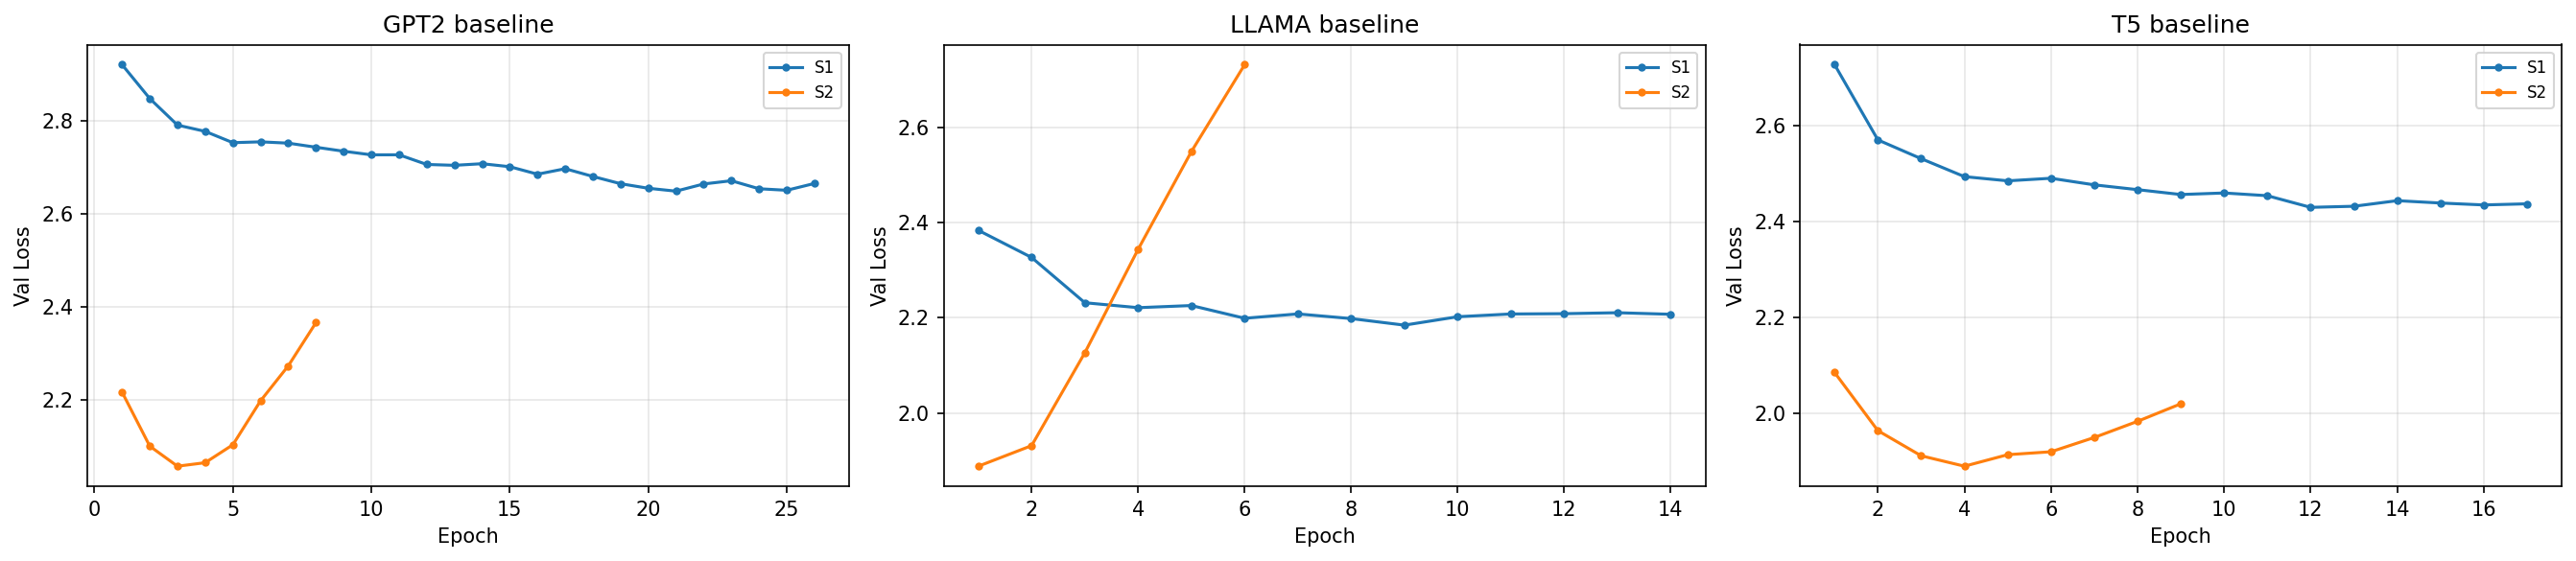

In [8]:
# Baseline training curves (S1 + S2) for each model
baseline_training = [r for r in training_results if r["tag"] == r["model"]]
models_with_data = sorted(set(r["model"] for r in baseline_training))

if models_with_data:
    fig, axes = plt.subplots(1, len(models_with_data), figsize=(6 * len(models_with_data), 4), squeeze=False)
    for idx, model in enumerate(models_with_data):
        ax = axes[0][idx]
        for r in baseline_training:
            if r["model"] != model:
                continue
            epochs = [h["epoch"] for h in r["history"]]
            val_loss = [h["val_loss"] for h in r["history"]]
            ax.plot(epochs, val_loss, marker="o", markersize=3, label=f"S{r['stage']}")
        ax.set_title(f"{model.upper()} baseline")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Val Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No baseline training results found.")

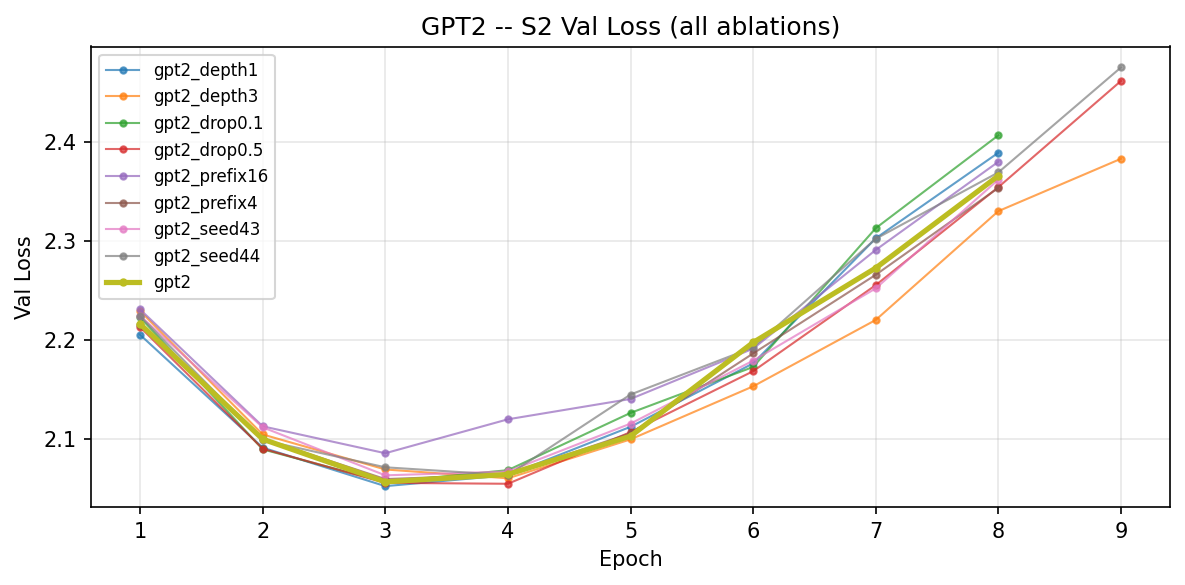

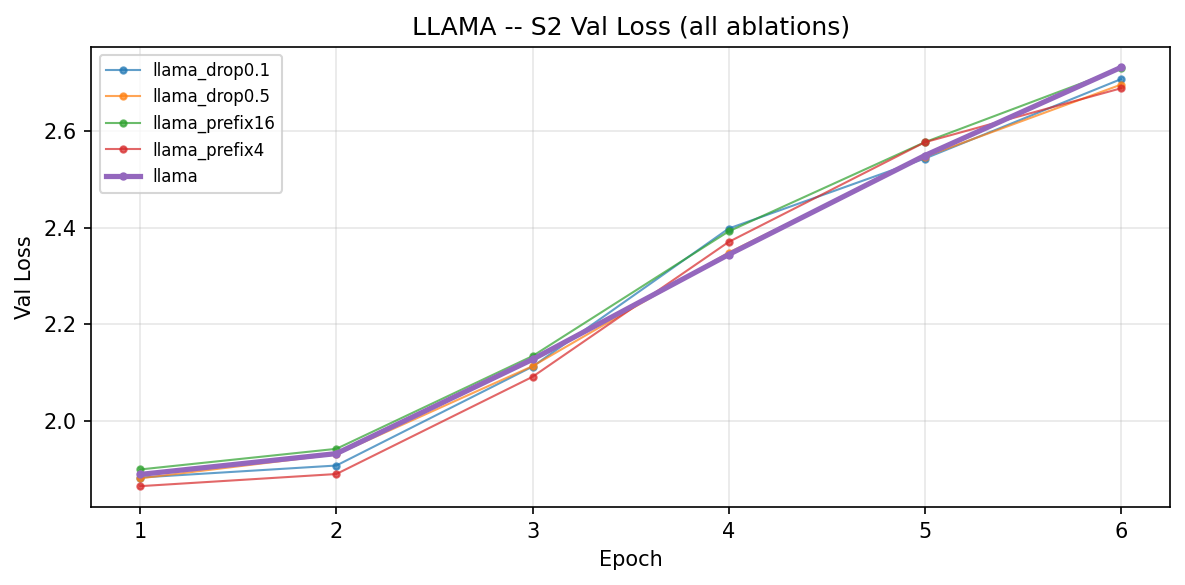

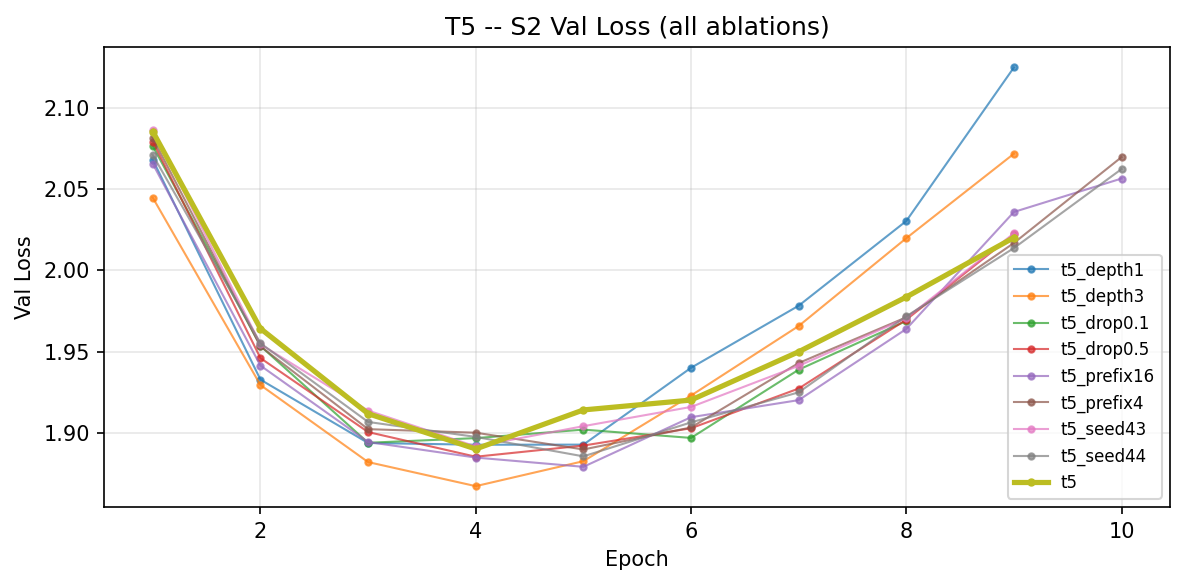

In [9]:
# S2 training curves for all ablation variants per model
s2_results = [r for r in training_results if r["stage"] == 2]
models_with_s2 = sorted(set(r["model"] for r in s2_results))

for model in models_with_s2:
    model_runs = [r for r in s2_results if r["model"] == model]
    fig, ax = plt.subplots(figsize=(8, 4))
    for r in model_runs:
        epochs = [h["epoch"] for h in r["history"]]
        val_loss = [h["val_loss"] for h in r["history"]]
        label = r["tag"]
        is_baseline = r["tag"] == r["model"]
        ax.plot(epochs, val_loss, marker="o", markersize=3, label=label,
                linewidth=2.5 if is_baseline else 1, alpha=1.0 if is_baseline else 0.7)
    ax.set_title(f"{model.upper()} -- S2 Val Loss (all ablations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Sample Predictions (Best / Median / Worst by FENSE)

In [10]:
import torch
from aac_metrics import evaluate as aac_evaluate


def score_predictions(predictions):
    """Score each prediction with sentence-level FENSE."""
    hyps = [p["hypothesis"].replace("\n", " ").strip() for p in predictions]
    refs = [[p["reference"].replace("\n", " ").strip()] for p in predictions]
    _, sents_scores = aac_evaluate(
        hyps, refs, metrics=["fense"],
        device="cuda" if torch.cuda.is_available() else "cpu",
    )
    fense_scores = sents_scores["fense"].tolist()
    scored = [{**p, "fense": s} for p, s in zip(predictions, fense_scores)]
    return sorted(scored, key=lambda x: x["fense"], reverse=True)


def show_predictions(scored, title, indices):
    """Display selected predictions."""
    print(f"\n--- {title} ---")
    for i in indices:
        if i >= len(scored):
            continue
        p = scored[i]
        print(f"  FENSE: {p['fense']:.4f}")
        print(f"  REF: {p['reference']}")
        print(f"  HYP: {p['hypothesis']}")
        print()

In [11]:
for model in MODELS:
    path = RESULTS_DIR / model / "ablations" / "arch" / f"{model}_ablation_{model}.json"
    d = load_json(path)
    if d is None:
        continue
    scored = score_predictions(d["predictions"])
    n = len(scored)
    mid = n // 2

    print(f"\n{'='*60}")
    print(f"  {model.upper()} -- Sample Predictions ({n} total)")
    print(f"{'='*60}")

    show_predictions(scored, "BEST (top 3)", [0, 1, 2])
    show_predictions(scored, "MEDIAN", [mid - 1, mid, mid + 1])
    show_predictions(scored, "WORST (bottom 3)", [n - 3, n - 2, n - 1])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  GPT2 -- Sample Predictions (529 total)

--- BEST (top 3) ---
  FENSE: 0.9183
  REF: A male vocalist sings this spirited song. The tempo is fast with intense drumming, loud harmonic electric guitar feedback, bass guitar , emphatic vocals and keyboard accompaniment. The song is a loud, progressive, powerful youthful and emphatic Hard Rock song.
  HYP: A male vocalist sings this spirited Rock song. The tempo is medium fast with keyboard harmony, steady drumming, groovy bass lines, keyboard accompaniment and vocal backup. The song is youthful, energetic, enthusiastic, enthusiastic, enthusiastic and electrifying. This song is a Hard Rock/Heavy Metal/Rock. This

  FENSE: 0.8787
  REF: The low quality recording features a rock song that consists of a melancholic male vocal singing over punchy kick and snare hits, shimmering ride cymbals, groovy bass guitar and acoustic rhythm guitar. It sounds emotional and heartfelt.
  HYP: The low quality recording features a rock song that consists of p

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  T5 -- Sample Predictions (529 total)

--- BEST (top 3) ---
  FENSE: 0.8309
  REF: This is a meditation music piece. There is an ambient synth sound playing very faint notes. There are natural sounds that can be heard in the piece such as the water flowing and the crickets chirping. The atmosphere of the piece is relaxing and soothing. The piece would suit perfectly as background music for a meditation video. It could also be playing in the background at spas and wellness centers.
  HYP: This is a meditation music piece. There is a mellow harp playing the main tune. The atmosphere is relaxing. This piece could be used in meditation videos. It could also be used in meditation videos.

  FENSE: 0.7984
  REF: This is an experimental rock/indie rock music piece. The rhythmic background consists of a peculiar 6/8 acoustic drum beat that has shifted kick drum hits. There are sleigh bells accompanying the drums. The synth bass is playing a simple and repeated theme. The atmosphere is eerie.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  LLAMA -- Sample Predictions (529 total)

--- BEST (top 3) ---
  FENSE: 0.8896
  REF: This is an instrumental heavy metal piece. The distorted electric guitar is playing an aggressive riff while accompanied by a bass guitar. In the rhythmic background, there is a slow but hard-hitting heavy metal beat played on the acoustic drums. The atmosphere is loud and violent. This piece can be used in the soundtrack of a movie/TV show involving crime. It could also be played at a rock bar or a sports venue.
  HYP: This is a hardcore metal music piece. There is a distorted electric guitar playing the main tune while a bass guitar is playing in the background. The rhythm is provided by a fast-paced metal drum beat. The atmosphere is aggressive and energetic. This piece could be used in the soundtrack of a hardcore metal movie. It could

  FENSE: 0.8841
  REF: The low quality recording features a live performance of a jazz song that consists of a tenor sax solo melody playing over mellow piano ch

## 7. Failure Cases

In [12]:
import re


def detect_failures(predictions):
    failures = []
    for p in predictions:
        hyp = p["hypothesis"].strip()
        reason = None

        if len(hyp) == 0:
            reason = "empty"
        elif len(hyp.split()) < 3:
            reason = "too short"
        else:
            words = hyp.lower().split()
            if len(set(words)) <= max(2, len(words) * 0.15):
                reason = "repetitive"
            elif re.search(r"(\b\w+\b)(?:\s+\1){4,}", hyp.lower()):
                reason = "word repetition"

        if reason:
            failures.append({**p, "failure": reason})
    return failures


for model in MODELS:
    for ablation_type in ["arch", "decoding"]:
        ablation_dir = RESULTS_DIR / model / "ablations" / ablation_type
        if not ablation_dir.exists():
            continue
        for f in sorted(ablation_dir.glob(f"{model}_ablation_*.json")):
            d = load_json(f)
            if d is None:
                continue
            tag = f.stem.replace(f"{model}_ablation_", "")
            failures = detect_failures(d["predictions"])
            if failures:
                print(f"{model}/{tag}: {len(failures)} failures out of {len(d['predictions'])}")
                for fail in failures[:3]:
                    print(f"  [{fail['failure']}]")
                    print(f"  REF: {fail['reference'][:100]}")
                    print(f"  HYP: {fail['hypothesis'][:100]}")
                    print()
                if len(failures) > 3:
                    print(f"  ... and {len(failures) - 3} more\n")

t5/t5_depth3: 4 failures out of 529
  [word repetition]
  REF: The excerpt starts off with 3 bass drum beats after which an explosion and a crumbling sound can be 
  HYP: The low quality recording features a wide wide wide wide wide wide reverberant snare, wide wide tinn

  [word repetition]
  REF: This clip features noises created by mixing output from different effect pedals. This is a synth noi
  HYP: This music is instrumental. The tempo is fast with a droning droning harmony of the droning droning 

  [word repetition]
  REF: A male vocalist sings this vigorous heavy metal song. The tempo is fast with intense  electric guita
  HYP: The low quality recording features a metal song that consists of a passionate male vocal singing ove

  ... and 1 more

llama/llama_drop0.5: 1 failures out of 529
  [word repetition]
  REF: The music is an instrumental gameplay track. The track has sounds of growling monsters, church bells
  HYP: This is a video game theme. There is a male voice narrati

## 8. Full Summary (All Ablations, Sorted by FENSE)

In [13]:
from IPython.display import HTML

display(HTML("""
<style>
@media print {
    .landscape-table { page-break-before: always; }
    @page { size: landscape; margin: 1cm; }
}
.landscape-table table { font-size: 10px; width: 100%; }
.landscape-table th, .landscape-table td { padding: 2px 4px; white-space: nowrap; }
</style>
"""))

for model in MODELS:
    model_df = eval_df[eval_df["model"] == model].copy()
    if len(model_df) == 0:
        continue
    avail = [m for m in METRICS if m in model_df.columns]
    table = model_df.set_index("tag")[avail].round(4)
    table = table.sort_values("FENSE", ascending=False)

    print(f"\n{model.upper()} -- All Ablations ({len(table)} configs)")
    styled = style_ablation_table(table, model, noise_floors, avail)
    styled = styled.set_table_attributes('class="landscape-table"')
    display(styled)


GPT2 -- All Ablations (41 configs)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
trim_ngram2,0.3171,0.0575,0.1210,0.2205,0.1092,0.1081,0.1087,0.5796
trim_rep1.2_ngram2_t0.3,0.2829,0.0454,0.1137,0.1970,0.1003,0.1062,0.1033,0.5775
trim_rep1.2_ngram3,0.2839,0.0407,0.1127,0.1944,0.0926,0.1045,0.0986,0.5766
trim_rep1.2_ngram2,0.2810,0.0409,0.1124,0.1931,0.0959,0.1042,0.1000,0.5766
trim_rep1.2,0.2834,0.0408,0.1124,0.1945,0.0924,0.1043,0.0983,0.5758
trim_rep1.3,0.2605,0.0374,0.1058,0.1843,0.0885,0.0990,0.0938,0.5723
trim_rep1.2_ngram2_t48,0.2011,0.0308,0.0938,0.1835,0.0692,0.1002,0.0847,0.5659
trim_incomplete,0.3091,0.0605,0.1202,0.2303,0.1106,0.1071,0.1088,0.5635
trim_rep1.8_ngram2_t0.3,0.2252,0.0348,0.0964,0.1708,0.0725,0.0940,0.0832,0.5589



T5 -- All Ablations (52 configs)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
trim_rep1.2,0.3045,0.0498,0.1158,0.2203,0.0863,0.0921,0.0892,0.5762
trim_beam5_ngram2,0.1923,0.0428,0.0918,0.1967,0.0878,0.1013,0.0945,0.5649
trim_rep1.3,0.2934,0.0424,0.1124,0.2065,0.0779,0.0987,0.0883,0.5640
trim_rep1.2_beam5_ngram2,0.1956,0.0442,0.0941,0.1949,0.0985,0.1023,0.1004,0.5618
trim_rep1.2_ngram2,0.2527,0.0296,0.0982,0.1904,0.0662,0.1000,0.0831,0.5593
trim_rep1.2_ngram2_t0.3,0.2500,0.0331,0.0978,0.1897,0.0611,0.0973,0.0792,0.5591
trim_rep1.3_ngram2,0.2629,0.0331,0.1018,0.1926,0.0711,0.1019,0.0865,0.5570
trim_rep1.2_ngram3,0.2725,0.0371,0.1017,0.2063,0.0738,0.0903,0.0821,0.5546
trim_rep1.5,0.2579,0.0264,0.1010,0.1817,0.0653,0.0916,0.0785,0.5533



LLAMA -- All Ablations (5 configs)


,BLEU-1,BLEU-4,METEOR,ROUGE-L,CIDEr-D,SPICE,SPIDEr,FENSE
tag,,,,,,,,
llama_drop0.1,0.3046,0.0568,0.1282,0.2320,0.1019,0.1040,0.1030,0.4065
llama_drop0.5,0.2912,0.0602,0.1279,0.2227,0.1074,0.1166,0.1120,0.4060
llama_prefix16,0.2610,0.0517,0.1216,0.2105,0.0820,0.1138,0.0979,0.4045
llama_prefix4,0.2987,0.0688,0.1252,0.2286,0.1333,0.1159,0.1246,0.3838
llama,0.3104,0.0669,0.1310,0.2365,0.1170,0.1156,0.1163,0.3626
